# Student Performance & Attendance Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc, precision_recall_curve)
import joblib, os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('../data/synthetic_student_data.csv')
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (1545, 9)


,Student_ID,Department,Semester,Admission_Year,Attendance_Pct,CGPA,Num_Backlogs,Marks_Trend,Study_Hours_Per_Day
0,STU1496,ECE,8,2023,79.7,10.00,0.0,Stable,11.3
1,STU0544,Electronics,1,2022,NaN,8.26,0.0,Improving,10.2
2,STU1269,Computer Science,2,2023,94.6,9.31,0.0,Improving,9.8
3,STU0529,IT,2,2023,NaN,5.18,1.0,Declining,10.4
4,STU1095,Civil,7,2022,95.8,8.14,0.0,Improving,9.0
5,STU0808,Civil,1,2025,77.0,8.57,3.0,Declining,NaN
6,STU0914,Computer Science,4,2024,78.5,NaN,1.0,Declining,7.5
7,STU1073,Civil,6,2022,91.4,7.04,1.0,Declining,11.0
8,STU1204,Computer Science,1,2022,100.0,8.72,1.0,Improving,9.8
9,STU1175,Electronics,1,2025,99.3,8.69,0.0,Stable,9.3


## Data Cleaning

In [3]:
# check missing values per column
df.isnull().sum()

Student_ID              0
Department              0
Semester                0
Admission_Year          0
Attendance_Pct         63
CGPA                   51
Num_Backlogs           26
Marks_Trend            28
Study_Hours_Per_Day    60
dtype: int64

In [4]:
# check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 22
Shape after removing duplicates: (1523, 9)


In [5]:
# strip whitespace from Student_ID
df['Student_ID'] = df['Student_ID'].str.strip()

# fix inconsistent department names
dept_mapping = {
    'comp science': 'Computer Science', 'computer science': 'Computer Science',
    'cs': 'Computer Science', 'computer sci': 'Computer Science',
    'mechanical': 'Mechanical', 'mech': 'Mechanical', 'MECHANICAL': 'Mechanical',
    'electronics': 'Electronics', 'ece': 'Electronics', 'elec': 'Electronics',
    'it': 'Information Technology', 'info tech': 'Information Technology',
    'information technology': 'Information Technology',
    'civil': 'Civil', 'CIVIL': 'Civil',
}

df['Department'] = df['Department'].str.strip()
df['Department'] = df['Department'].apply(lambda x: dept_mapping.get(x.lower(), x) if pd.notna(x) else x)

# fix Semester column — mixed types (int + string)
df['Semester'] = pd.to_numeric(df['Semester'], errors='coerce').astype('Int64')

# fix out-of-range attendance (>100 or <0)
df.loc[df['Attendance_Pct'] > 100, 'Attendance_Pct'] = np.nan

# fix negative CGPA values
df.loc[df['CGPA'] < 0, 'CGPA'] = np.nan

# fill missing numerics with median
for col in ['Attendance_Pct', 'CGPA', 'Study_Hours_Per_Day', 'Num_Backlogs']:
    df[col] = df[col].fillna(df[col].median())

# fill missing Marks_Trend with mode
df['Marks_Trend'] = df['Marks_Trend'].fillna(df['Marks_Trend'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:


Student_ID             0
Department             0
Semester               0
Admission_Year         0
Attendance_Pct         0
CGPA                   0
Num_Backlogs           0
Marks_Trend            0
Study_Hours_Per_Day    0
dtype: int64


## Exploratory Data Analysis (EDA)

In [6]:
# define target — at-risk if low CGPA, low attendance, or 2+ backlogs
df['At_Risk'] = ((df['CGPA'] < 6.0) | (df['Attendance_Pct'] < 75) | (df['Num_Backlogs'] >= 2)).astype(int)

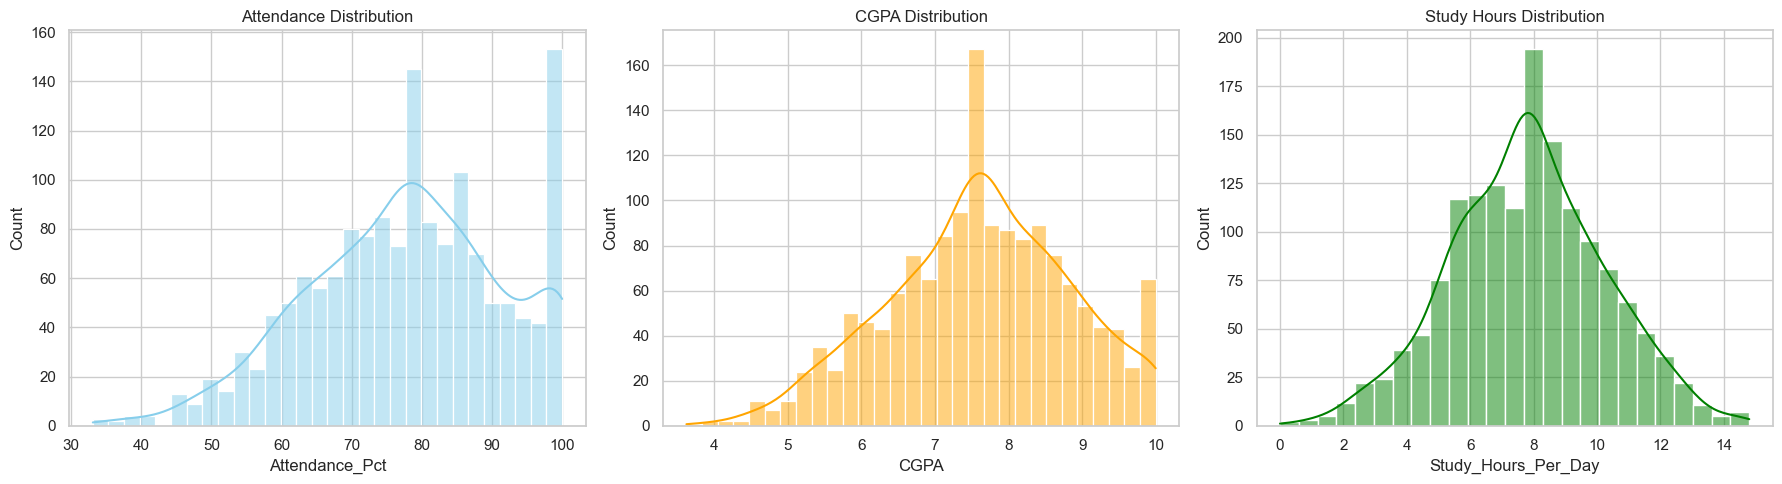

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Attendance_Pct'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Attendance Distribution')

sns.histplot(df['CGPA'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('CGPA Distribution')

sns.histplot(df['Study_Hours_Per_Day'], bins=25, kde=True, ax=axes[2], color='green')
axes[2].set_title('Study Hours Distribution')

plt.tight_layout()
plt.show()

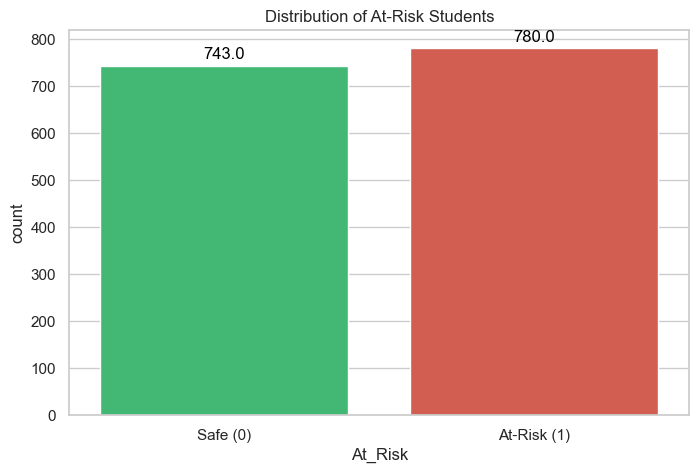

In [8]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='At_Risk', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of At-Risk Students')
plt.xticks([0, 1], ['Safe (0)', 'At-Risk (1)'])
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

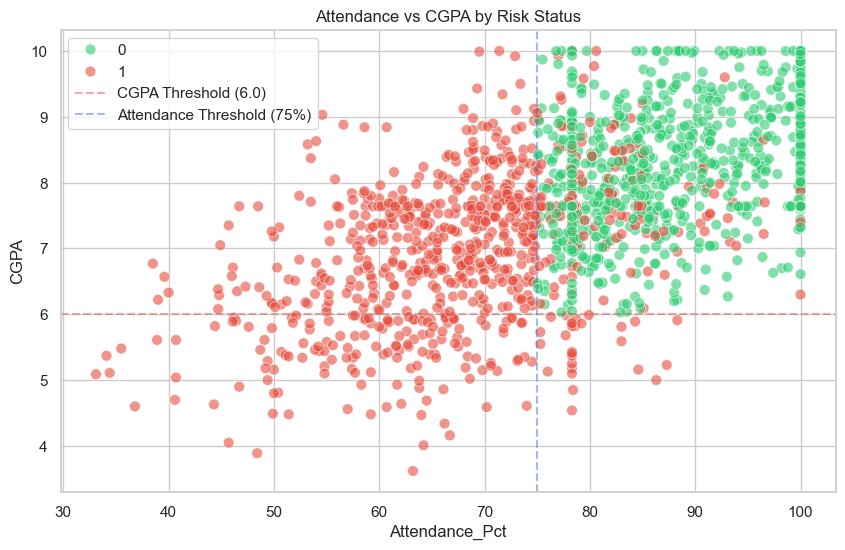

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Attendance_Pct', y='CGPA', hue='At_Risk', palette=['#2ecc71', '#e74c3c'], alpha=0.6, s=60)
plt.title('Attendance vs CGPA by Risk Status')
plt.axhline(y=6.0, color='r', linestyle='--', alpha=0.5, label='CGPA Threshold (6.0)')
plt.axvline(x=75, color='b', linestyle='--', alpha=0.5, label='Attendance Threshold (75%)')
plt.legend()
plt.show()

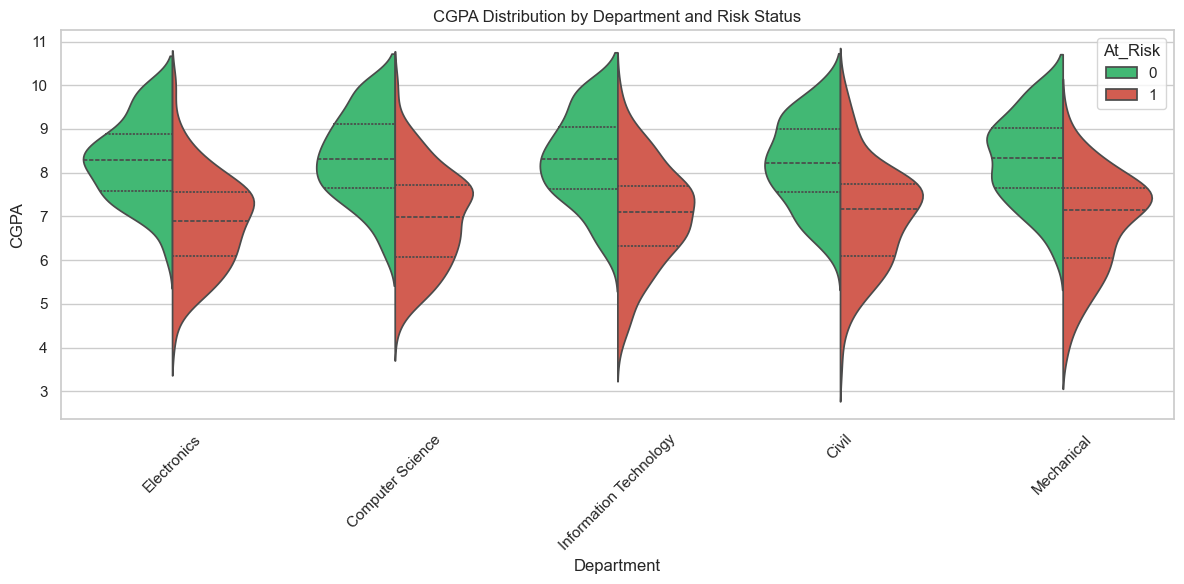

In [10]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Department', y='CGPA', hue='At_Risk', split=True, inner="quart", palette=['#2ecc71', '#e74c3c'])
plt.title('CGPA Distribution by Department and Risk Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

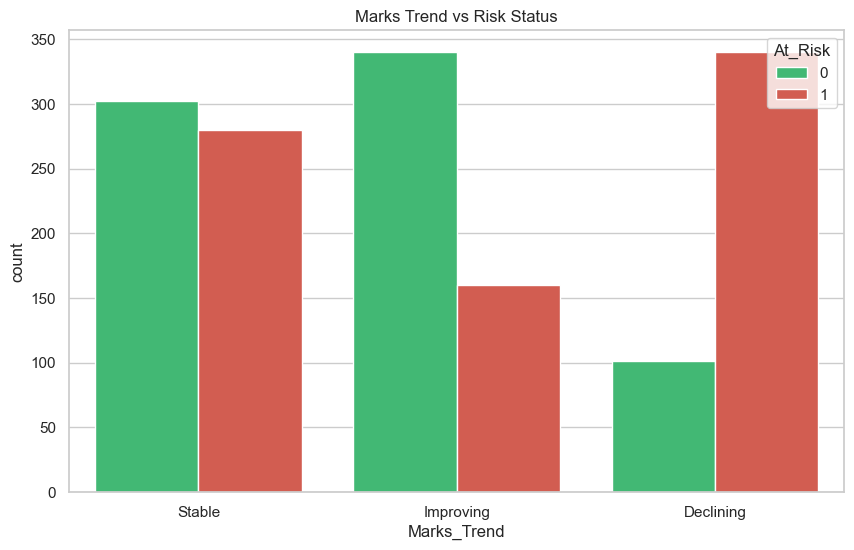

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Marks_Trend', hue='At_Risk', palette=['#2ecc71', '#e74c3c'])
plt.title('Marks Trend vs Risk Status')
plt.show()

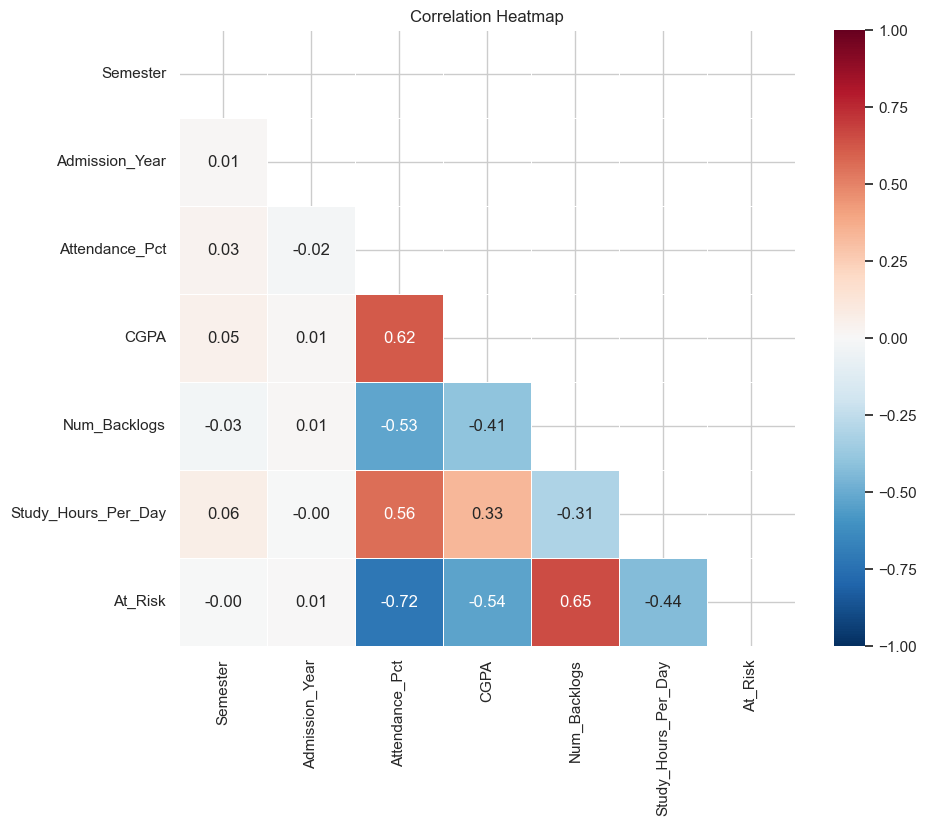

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

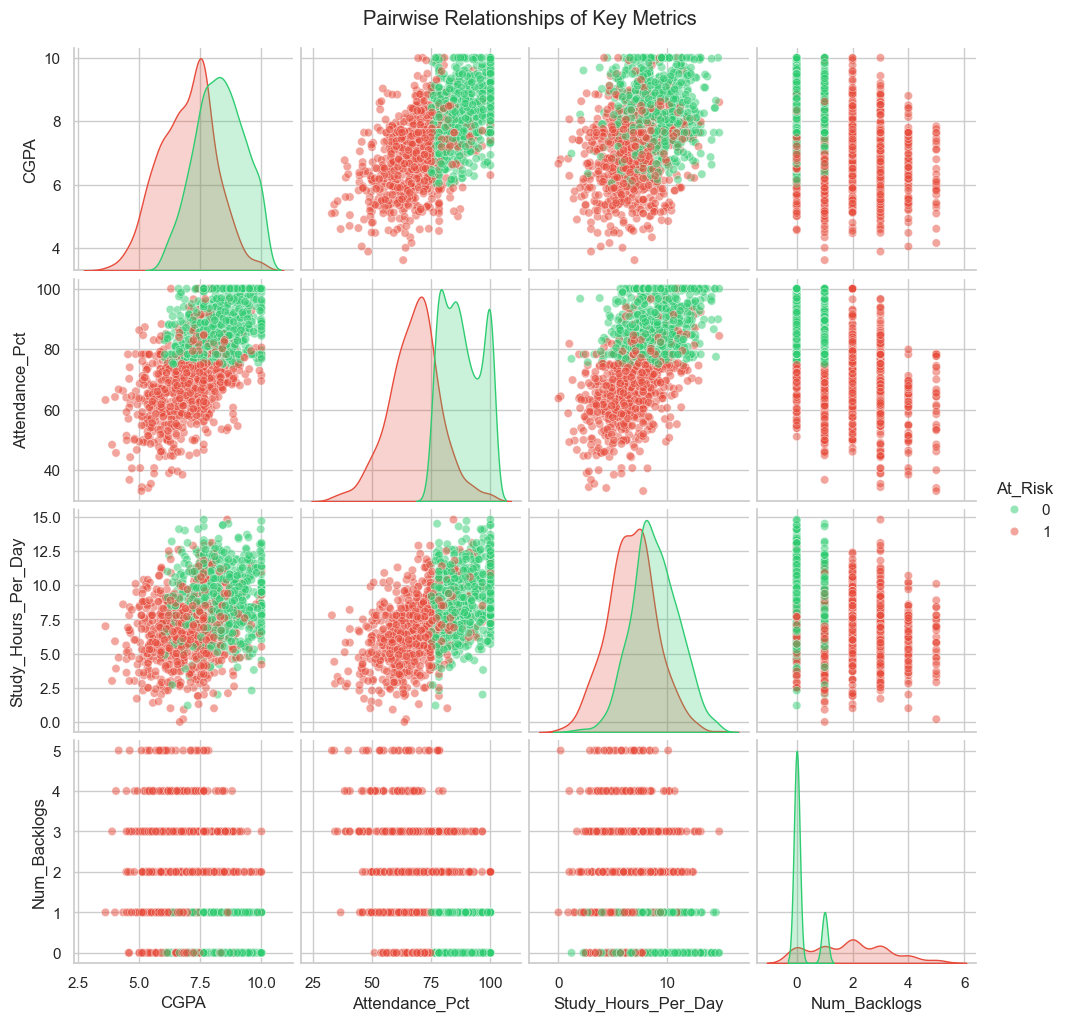

In [13]:
sns.pairplot(df[['CGPA', 'Attendance_Pct', 'Study_Hours_Per_Day', 'Num_Backlogs', 'At_Risk']], hue='At_Risk', palette=['#2ecc71', '#e74c3c'], plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships of Key Metrics', y=1.02)
plt.show()

## Feature Engineering & Data Splitting

In [14]:
df_model = df.drop(['Student_ID'], axis=1)

le_dept = LabelEncoder()
df_model['Department'] = le_dept.fit_transform(df_model['Department'])

le_trend = LabelEncoder()
df_model['Marks_Trend'] = le_trend.fit_transform(df_model['Marks_Trend'])

X = df_model.drop('At_Risk', axis=1)
y = df_model['At_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1218, 8)
Testing set: (305, 8)


## Machine Learning Modeling

In [15]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_prob

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    }

results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
results_df.style.background_gradient(cmap='Greens')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
XGBoost,0.996721,1.000000,0.993590,0.996785,1.000000
Random Forest,0.993443,0.993590,0.993590,0.993590,0.999871
Logistic Regression,0.937705,0.925466,0.955128,0.940063,0.981544


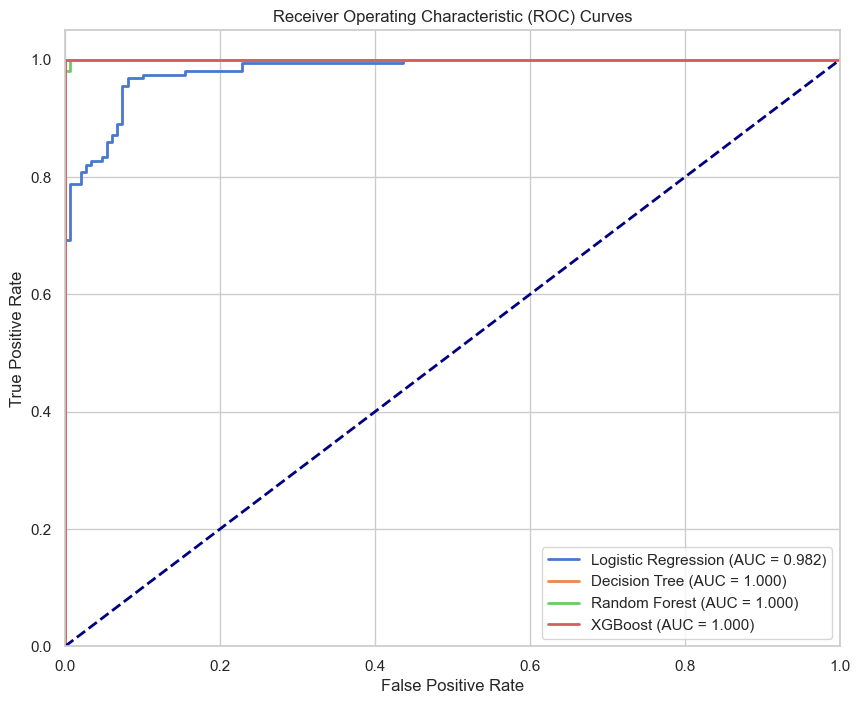

In [16]:
# Plot ROC Curves for all models
plt.figure(figsize=(10, 8))
for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

## Hyperparameter Tuning (XGBoost)

In [17]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid.fit(X_train_scaled, y_train)

best_xgb = grid.best_estimator_
print(f"Best parameters found: {grid.best_params_}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [18]:
y_pred_best = best_xgb.predict(X_test_scaled)
y_prob_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("Classification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_best, target_names=['Safe', 'At-Risk']))

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

        Safe       0.99      1.00      1.00       149
     At-Risk       1.00      0.99      1.00       156

    accuracy                           1.00       305
   macro avg       1.00      1.00      1.00       305
weighted avg       1.00      1.00      1.00       305



## Feature Importance & Model Interpretation

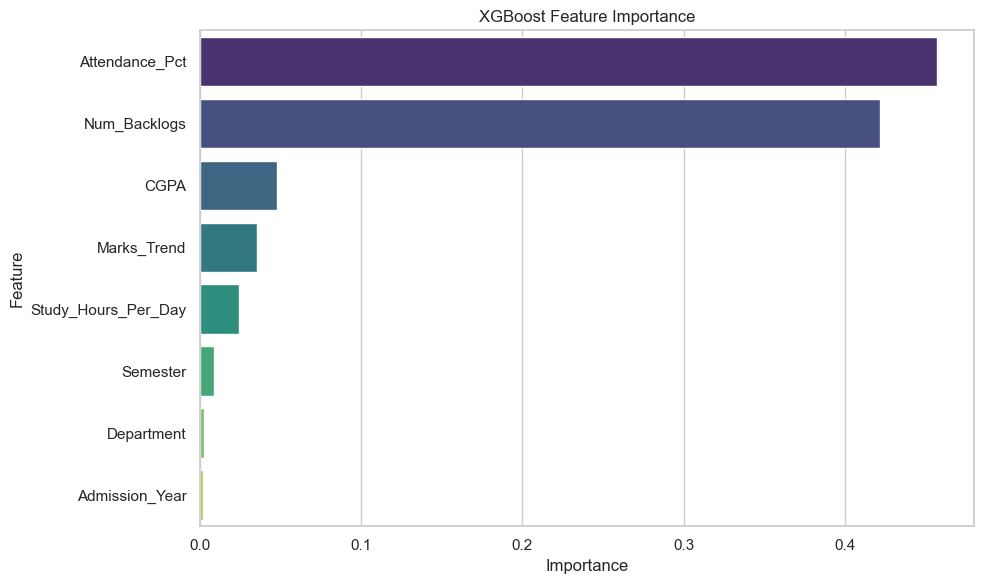

In [19]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

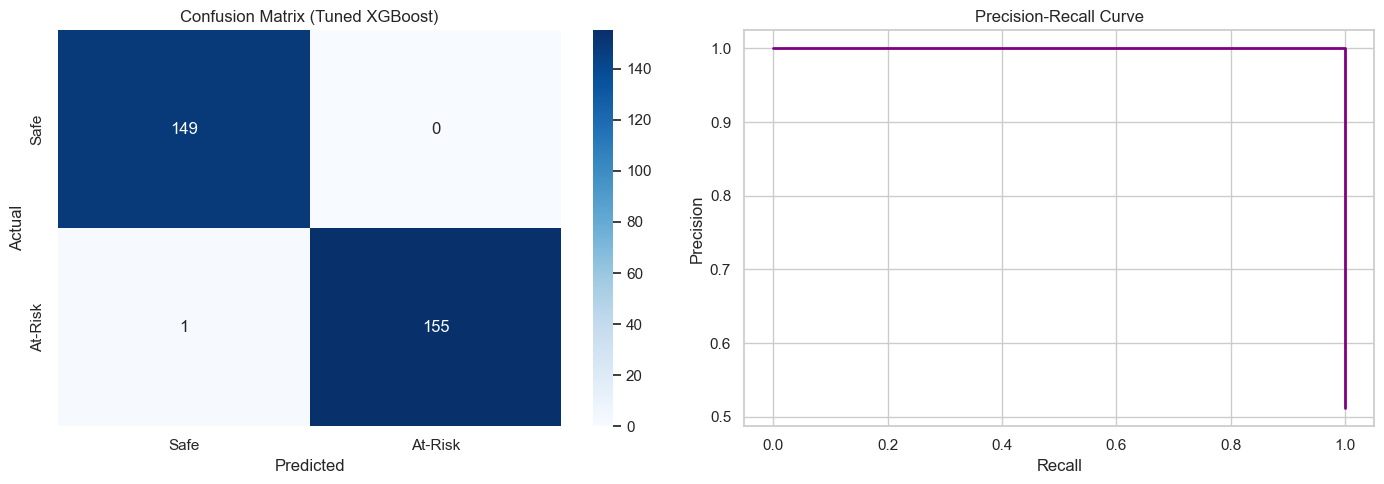

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Safe', 'At-Risk'], yticklabels=['Safe', 'At-Risk'])
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].set_title('Confusion Matrix (Tuned XGBoost)')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_best)
axes[1].plot(recall, precision, lw=2, color='purple')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Save Final Model

In [21]:
os.makedirs('../models', exist_ok=True)
model_path = '../models/final_xgboost_model.pkl'
joblib.dump(best_xgb, model_path)
print(f"Final model saved to: {model_path}")

Final model saved to: ../models/final_xgboost_model.pkl
